In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Settings
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="darkgrid")
Path("charts").mkdir(exist_ok=True)

# Load data
df = pd.read_csv("data/cleaned/jobs_cleaned.csv")
print(f" Loaded {len(df)} jobs, {df.shape[1]} columns")
print(f"\n Roles:\n{df['Role'].value_counts()}")

 Loaded 929 jobs, 15 columns

 Roles:
Role
Machine Learning Engineer    167
BI Analyst                   166
Business Analyst             165
Data Scientist               157
Data Engineer                152
Data Analyst                 122
Name: count, dtype: int64


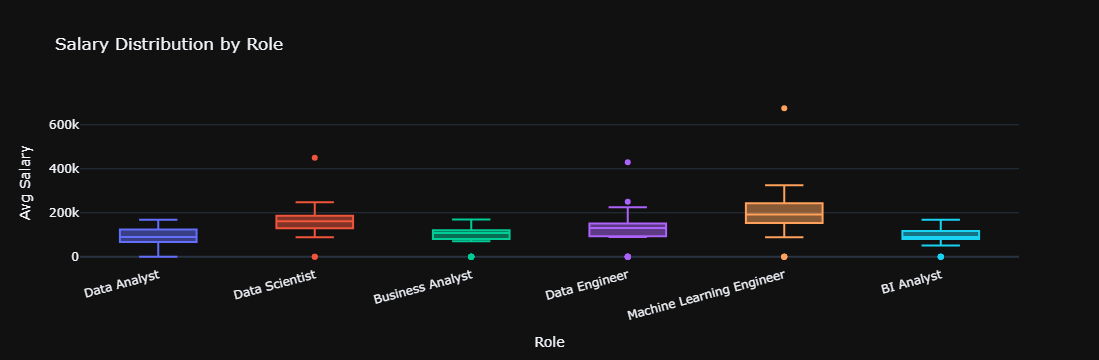

In [2]:
# Salary Distribution by Role / EDA
fig = px.box(
    df[df["Avg Salary"] > 0],
    x="Role", y="Avg Salary",
    color="Role",
    title="Salary Distribution by Role",
    template="plotly_dark"
)
fig.update_layout(showlegend=False, xaxis_tickangle=-15)
fig.write_image("charts/01_salary_by_role.png")
fig.show()

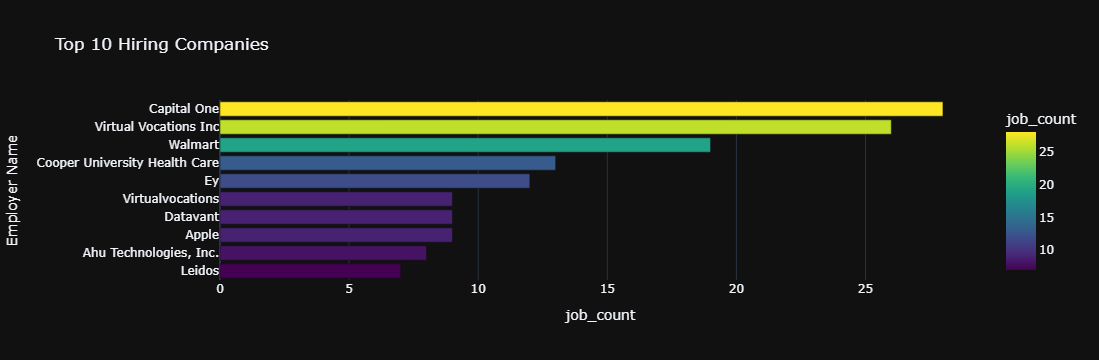

In [3]:
# Top 10 Hiring Companies
top_companies = (df.groupby("Employer Name")
                   .size()
                   .reset_index(name="job_count")
                   .nlargest(10, "job_count"))

fig = px.bar(top_companies, x="job_count", y="Employer Name",
             orientation="h", color="job_count",
             color_continuous_scale="viridis",
             title="Top 10 Hiring Companies",
             template="plotly_dark")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.write_image("charts/02_top_companies.png")
fig.show()

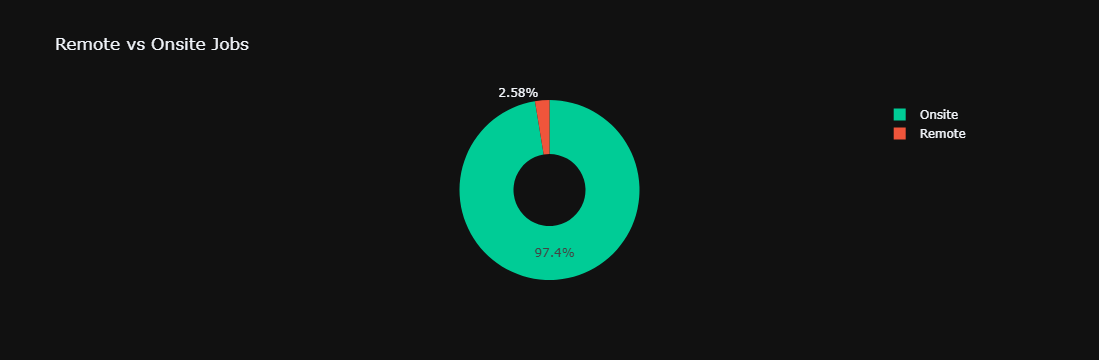

In [4]:
# Remote v/s Onsite JOb
remote_counts = df["Job Is Remote"].map({True: "Remote", False: "Onsite"}).value_counts().reset_index()
remote_counts.columns = ["Type", "Count"]

fig = px.pie(remote_counts, names="Type", values="Count",
             title="Remote vs Onsite Jobs",
             color_discrete_sequence=["#00CC96", "#EF553B"],
             template="plotly_dark", hole=0.4)
fig.write_image("charts/03_remote_vs_onsite.png")
fig.show()

In [5]:
# Top 20 Cities by Job Count
fig = px.bar(
    df[df["Job City"] != "Unknown"].groupby("Job City").size().reset_index(name="job_count").nlargest(20, "job_count"),
    x="Job City", y="job_count", color="job_count",
    color_continuous_scale="plasma",
    title="Top 20 Cities by Job Count",
    template="plotly_dark"
)
fig.update_layout(xaxis_tickangle=-45)
fig.write_image("charts/04_top_cities.png")
fig.show()

In [6]:
# Heatmap: Job Distribution by Role and State
pivot = (df[df["Job State"] != "Unknown"]
         .groupby(["Job State", "Role"])
         .size()
         .unstack(fill_value=0))

fig = px.imshow(pivot, color_continuous_scale="viridis",
                title="Job Distribution by Role & State",
                template="plotly_dark", aspect="auto")
fig.write_image("charts/05_role_state_heatmap.png")
fig.show()

In [7]:
# Salary by Employment Type
fig = px.box(df[df["Avg Salary"] > 0], x="Job Employment Type", y="Avg Salary",
             color="Job Employment Type", title="Salary by Employment Type",
             template="plotly_dark").update_layout(showlegend=False)
fig.write_image("charts/06_salary_employment_type.png")
fig.show()

In [8]:
# Correlation Heatmap
fig = px.imshow(df[["Avg Salary", "Has Salary", "Job Is Remote"]].corr().round(2),
                text_auto=True, color_continuous_scale="RdBu",
                title="Feature Correlation Heatmap", template="plotly_dark")
fig.write_image("charts/07_correlation_heatmap.png")
fig.show()

In [9]:
# NLP Setup
import spacy, nltk, re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
from nltk.util import ngrams

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)
nlp = spacy.load("en_core_web_sm")

# Clean text function
clean = lambda text: re.sub(r"[^a-zA-Z\s]", "", str(text).lower())

print(" NLP ready!")

 NLP ready!


In [10]:
# Top 20 In-Demand Skills
SKILLS = ["python","sql","tableau","power bi","excel","machine learning","deep learning",
          "spark","aws","azure","gcp","docker","kubernetes","tensorflow","pytorch",
          "scikit-learn","pandas","numpy","r","scala","kafka","airflow","dbt",
          "looker","snowflake","databricks","nlp","statistics","visualization","communication"]

skills_df = pd.DataFrame(
    Counter(s for d in df["Job Description"].str.lower() for s in SKILLS if s in d).most_common(20),
    columns=["Skill", "Count"]
)

fig = px.bar(skills_df, x="Count", y="Skill", orientation="h", color="Count",
             color_continuous_scale="viridis", title="Top 20 In-Demand Skills",
             template="plotly_dark").update_layout(yaxis={"categoryorder":"total ascending"})
fig.write_image("charts/08_top_skills.png")
fig.show()

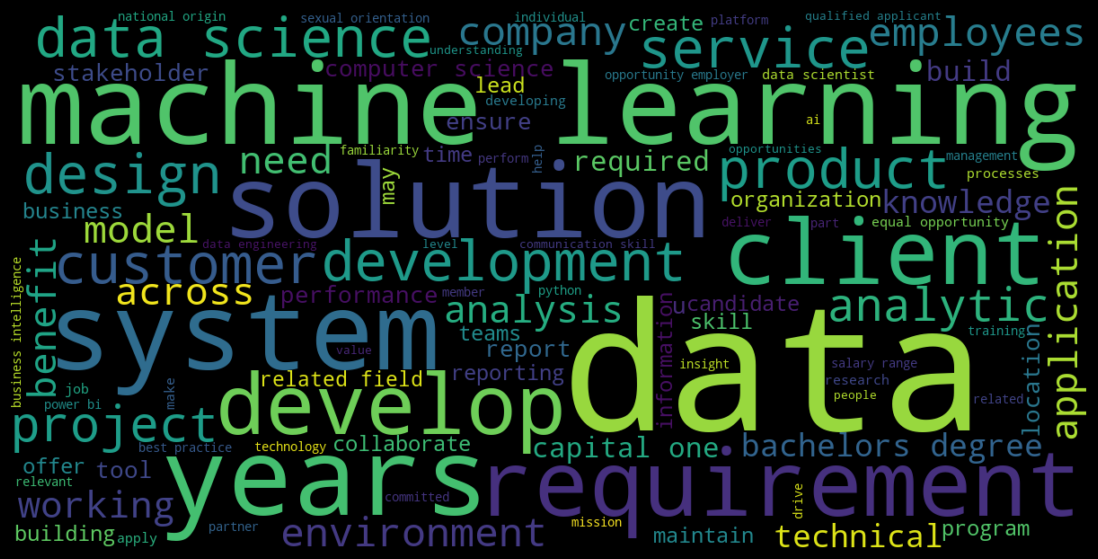

In [13]:
# Word Cloud with Stopwords Removed
EXTRA_STOPS = {"will","including","must","provide","role","position",
               "ability","work","team","year","employee","require",
               "experience","support","using","use","also","within"}

wc = WordCloud(width=1200, height=600, background_color="black",
               colormap="viridis", max_words=100,
               stopwords=set(stopwords.words("english")) | EXTRA_STOPS).generate(
               " ".join(df["Job Description"].dropna().apply(clean)))

plt.figure(figsize=(15,7), facecolor="black")
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.savefig("charts/09_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

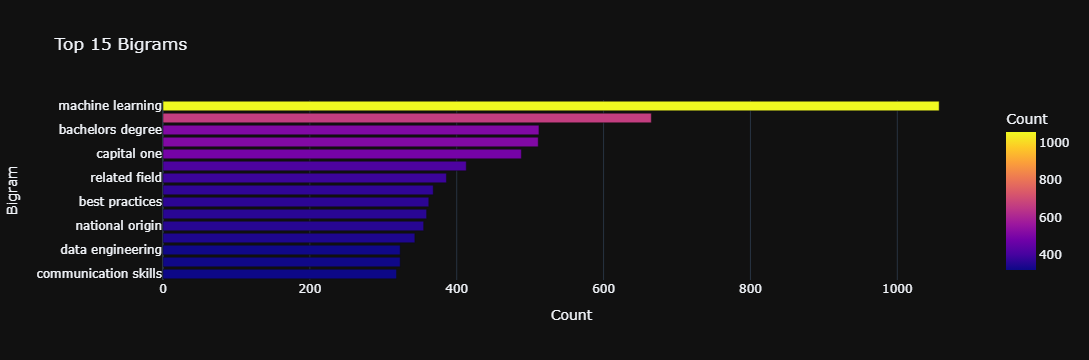

In [15]:
# Bigram Analysis - Optimized
STOP = set(stopwords.words("english")) | EXTRA_STOPS

bigram_df = pd.DataFrame(
    Counter(
        " ".join(g) for desc in df["Job Description"].dropna()
        for g in ngrams(clean(desc).split(), 2)
        if g[0] not in STOP and g[1] not in STOP
    ).most_common(15), columns=["Bigram", "Count"]
)

fig = px.bar(bigram_df, x="Count", y="Bigram", orientation="h",
             color="Count", color_continuous_scale="plasma",
             title="Top 15 Bigrams", template="plotly_dark"
             ).update_layout(yaxis={"categoryorder":"total ascending"})
fig.write_image("charts/10_bigrams.png")
fig.show()

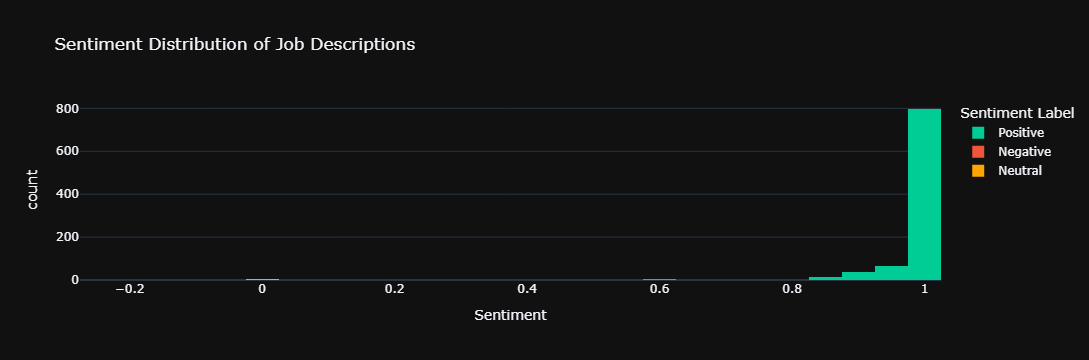

In [16]:
# Sentiment Analysis on Job Descriptions
sia = SentimentIntensityAnalyzer()

df["Sentiment"] = df["Job Description"].dropna().apply(lambda x: sia.polarity_scores(x)["compound"])
df["Sentiment Label"] = pd.cut(df["Sentiment"], bins=[-1,-0.05,0.05,1], labels=["Negative","Neutral","Positive"])

fig = px.histogram(df, x="Sentiment", color="Sentiment Label",
                   color_discrete_map={"Positive":"#00CC96","Neutral":"#FFA500","Negative":"#EF553B"},
                   title="Sentiment Distribution of Job Descriptions",
                   template="plotly_dark", nbins=50)
fig.write_image("charts/11_sentiment.png")
fig.show()

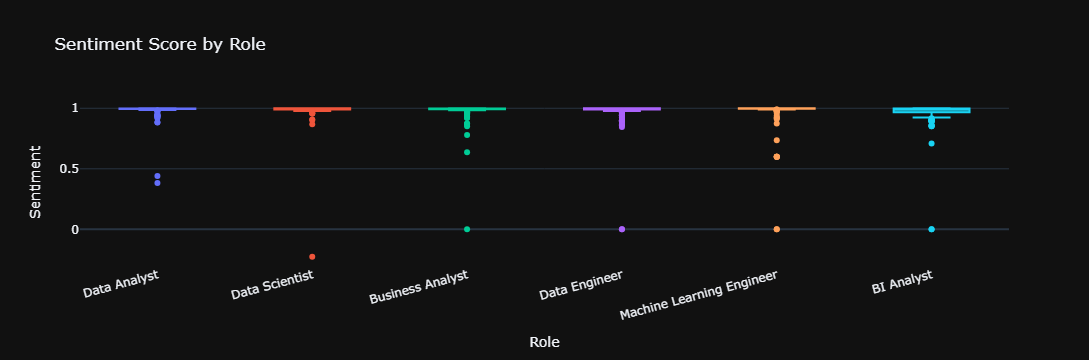

In [17]:
# Sentiment by Role
fig = px.box(df, x="Role", y="Sentiment", color="Role",
             title="Sentiment Score by Role",
             template="plotly_dark").update_layout(showlegend=False, xaxis_tickangle=-15)
fig.write_image("charts/12_sentiment_by_role.png")
fig.show()